# ATLAS v0

## LLM-Based Knowledge Extraction and Knowledge Graph Construction

Agentic Text and Literature Analysis System

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root / "src"))

In [2]:
# Imports

import networkx as nx
import matplotlib.pyplot as plt

from atlas.extractors import MistralExtractor
from atlas.graph_builder import GraphBuilder

from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")

In [3]:
# Text (source: https://arxiv.org/abs/2410.20424)

text = """
Data science tasks involving tabular data present complex challenges that require sophisticated problem-solving approaches. We propose AutoKaggle, a powerful and user-centric framework that assists data scientists in completing daily data pipelines through a collaborative multi-agent system. AutoKaggle implements an iterative development process that combines code execution, debugging, and comprehensive unit testing to ensure code correctness and logic consistency. The framework offers highly customizable workflows, allowing users to intervene at each phase, thus integrating automated intelligence with human expertise. Our universal data science toolkit, comprising validated functions for data cleaning, feature engineering, and modeling, forms the foundation of this solution, enhancing productivity by streamlining common tasks. We selected 8 Kaggle competitions to simulate data processing workflows in real-world application scenarios. Evaluation results demonstrate that AutoKaggle achieves a validation submission rate of 0.85 and a comprehensive score of 0.82 in typical data science pipelines, fully proving its effectiveness and practicality in handling complex data science tasks.
"""

In [4]:
# LLM-Based Knowledge Extraction

extractor = MistralExtractor(
    api_key=api_key
)

result = extractor.extract(text)

result

ExtractionResult(entities=[Entity(name='AutoKaggle', type='Framework'), Entity(name='Kaggle', type='Benchmark'), Entity(name='multi-agent system', type='ScientificConcept'), Entity(name='code execution', type='ScientificConcept'), Entity(name='debugging', type='ScientificConcept'), Entity(name='unit testing', type='ScientificConcept'), Entity(name='data cleaning', type='ScientificConcept'), Entity(name='feature engineering', type='ScientificConcept'), Entity(name='modeling', type='ScientificConcept')], relationships=[Relationship(source='AutoKaggle', relation='implements', target='multi-agent system'), Relationship(source='AutoKaggle', relation='implements', target='iterative development process'), Relationship(source='iterative development process', relation='combines', target='code execution'), Relationship(source='iterative development process', relation='combines', target='debugging'), Relationship(source='iterative development process', relation='combines', target='unit testing'),

In [5]:
print(f"Entities: {len(result.entities)}")
print(f"Relationships: {len(result.relationships)}")

Entities: 9
Relationships: 10


In [6]:
# Build Knowledge Graph

builder = GraphBuilder()

graph = builder.build(result)

In [7]:
# Graph Statistics

print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")

Nodes: 11
Edges: 10


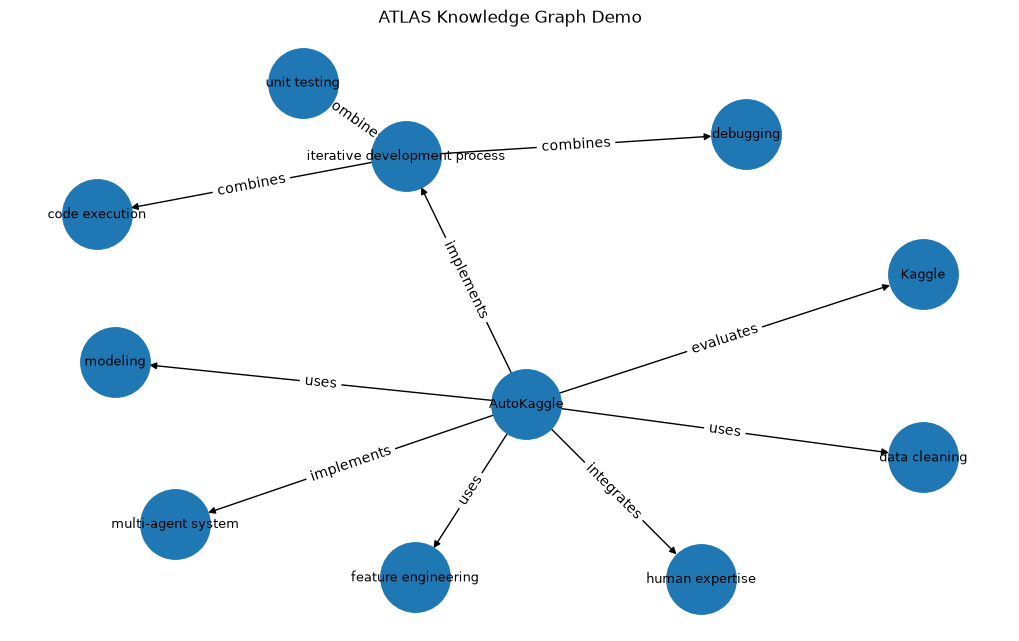

In [8]:
# Visualization

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(
    graph,
    seed=42
)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

edge_labels = nx.get_edge_attributes(
    graph,
    "relation"
)

nx.draw_networkx_edge_labels(
    graph,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "ATLAS Knowledge Graph Demo"
)

plt.show()

In [9]:
# Export Graph

import json
import networkx as nx

with open("graph.json", "w") as f:
    json.dump(
        nx.node_link_data(graph),
        f,
        indent=2
    )

In [10]:
nx.write_graphml(graph, "atlas_graph.graphml")